# 3 — Hankel matrices, predictive states, and WFA reconstruction

**Worked solutions · draft for the Iliad Intensive**

An HMM belief is a posterior over the hidden states of a **chosen
model**. Can we define predictive state directly from observable
word probabilities instead?

In the core path you will:

- use consistency constraints to interrogate a table of word
  probabilities without mistaking bookkeeping for the main idea;
- arrange those probabilities into a Hankel matrix;
- distinguish joint rows from conditional predictive rows;
- separate a generic finite-block dependency from evidence for a
  finite predictive dimension;
- choose future tests as predictive-state-representation (PSR)
  coordinates;
- connect the observable construction back to HMM beliefs without
  treating latent states as ground truth.

Five numbered **CORE** tasks (50 minutes total) and an eight-minute
HMM factorization form the complete 55–65 minute path. Anything
marked **STRETCH**, including the Z1R **BELIEF ↔ PSR BRIDGE**, is
modular. The final WFA section is an instructor demo: students
interpret one surprising operator rather than spend the core doing
determinant or matrix-inversion arithmetic.


> <span lang="la">*longum iter est per praecepta, breve et efficax per exempla. multum interest utrum non velit an nesciat. velle non discitur.*</span>
>
> — **Seneca the Younger**, adapted from *Moral Letters to Lucilius* 6.5, 90.46, and 81.13


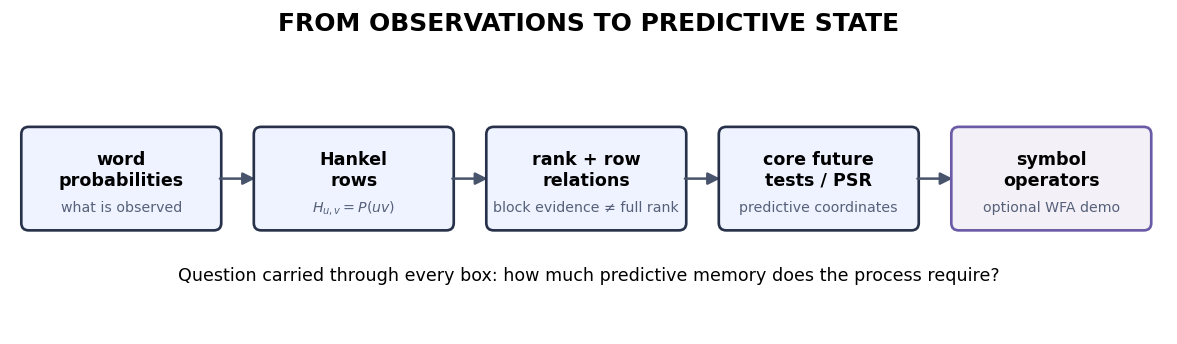

In [1]:
# ORIENTATION VISUAL — the observable route through this notebook.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12.4, 3.15))
ax.set(xlim=(0, 12.4), ylim=(0, 3.15))
ax.axis("off")

labels = [
    ("word\nprobabilities", "what is observed"),
    ("Hankel\nrows", r"$H_{u,v}=P(uv)$"),
    ("rank + row\nrelations", "block evidence ≠ full rank"),
    ("core future\ntests / PSR", "predictive coordinates"),
    ("symbol\noperators", "optional WFA demo"),
]
xs = [.15, 2.65, 5.15, 7.65, 10.15]
for index, ((title, subtitle), x) in enumerate(zip(labels, xs)):
    color = "#eef3ff" if index < 4 else "#f3f0f8"
    edge = "#27324a" if index < 4 else "#6b5aa6"
    ax.add_patch(FancyBboxPatch(
        (x, 1.15), 2.05, 1.02,
        boxstyle="round,pad=.05,rounding_size=.08",
        fc=color, ec=edge, lw=1.6,
    ))
    ax.text(x+1.025, 1.75, title, ha="center", va="center",
            fontsize=10.5, fontweight="bold")
    ax.text(x+1.025, 1.34, subtitle, ha="center", va="center",
            fontsize=8.5, color="#566179")
    if index < 4:
        ax.add_patch(FancyArrowPatch(
            (x+2.05, 1.66), (xs[index+1], 1.66),
            arrowstyle="-|>", mutation_scale=15, lw=1.5,
            color="#47546b",
        ))
ax.text(
    6.2, .55,
    "Question carried through every box: "
    "how much predictive memory does the process require?",
    ha="center", fontsize=10.5,
)
ax.set_title(
    "FROM OBSERVATIONS TO PREDICTIVE STATE",
    fontsize=15, fontweight="bold",
)
plt.show()


## Start from observations, not a hidden model

A stationary binary process has supplied the table below. No hidden
states have been specified: $\Pr(w)$ is the primitive observable.
Two entries are concealed so that you use the constraints once,
without spending the section on fraction bookkeeping.

| length | observed word probabilities |
|---|---|
| 0 | $\Pr(\epsilon)=1$ |
| 1 | $\Pr(0)=2/3,\quad\Pr(1)=1/3$ |
| 2 | $\Pr(00)=1/2,\quad\Pr(01)=?,\quad\Pr(10)=1/6,\quad\Pr(11)=1/6$ |
| 3 | $\Pr(000)=3/8,\ \Pr(001)=1/8,\ \Pr(010)=1/12,\ \Pr(011)=1/12$ |
|   | $\Pr(100)=1/8,\ \Pr(101)=?,\ \Pr(110)=1/12,\ \Pr(111)=1/12$ |

For a stationary process, a word can be extended on either side:

$$
\Pr(u)=\Pr(u0)+\Pr(u1)
=\Pr(0u)+\Pr(1u).
$$


## CORE 1/5 — Interrogate the observable table (8 minutes)

1. Use right-extension consistency to recover only the two missing
   entries $\Pr(01)$ and $\Pr(101)$.
2. Check left-extension consistency in two nontrivial places:
   $\Pr(00)=\Pr(000)+\Pr(100)$ and
   $\Pr(10)=\Pr(010)+\Pr(110)$. What assumption makes these
   identities appropriate?
3. Calculate $\Pr(0\mid0)$ and $\Pr(0\mid1)$. Propose—not
   prove—the simplest continuation rule suggested by them.
4. **STRETCH — continuation check.** Under that hypothesis, predict
   the withheld value $\Pr(1010)$. Then reveal the check cell.

<details><summary>Hint</summary>
Under a first-order continuation,
$\Pr(1010)=\Pr(101)\Pr(0\mid1)$.
</details>


#### Worked solution

Right-extension consistency gives

$$
\begin{aligned}
\Pr(01)&=\Pr(0)-\Pr(00)=\frac16,\\
\Pr(101)&=\Pr(10)-\Pr(100)=\frac1{24}.
\end{aligned}
$$

The two left-extension checks are
$3/8+1/8=1/2$ and $1/12+1/12=1/6$. They rely on stationarity:
observing $u$ at a fixed location has the same distribution after
shifting the time origin, so we may marginalize the preceding
symbol.

The one-step conditionals are

$$
\Pr(0\mid0)=\frac{1/2}{2/3}=\frac34,\qquad
\Pr(0\mid1)=\frac{1/6}{1/3}=\frac12.
$$

The simplest hypothesis is a first-order Markov continuation whose
next-symbol law depends only on the final symbol. It predicts
$\Pr(1010)=(1/24)(1/2)=1/48$. Agreement with one withheld value
supports this continuation but does not logically identify it from
a finite table.


In [2]:
# CHECK — the completed observable word table.
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt

word_p = {
    "": Fraction(1, 1),
    "0": Fraction(2, 3), "1": Fraction(1, 3),
    "00": Fraction(1, 2), "01": Fraction(1, 6),
    "10": Fraction(1, 6), "11": Fraction(1, 6),
    "000": Fraction(3, 8), "001": Fraction(1, 8),
    "010": Fraction(1, 12), "011": Fraction(1, 12),
    "100": Fraction(1, 8), "101": Fraction(1, 24),
    "110": Fraction(1, 12), "111": Fraction(1, 12),
    "1010": Fraction(1, 48),
}
for length in range(4):
    layer = {w: p for w, p in word_p.items() if len(w) == length}
    print(f"length {length}:", layer,
          "sum =", sum(layer.values(), Fraction(0)))
print("WITHHELD CHECK — P(1010) =", word_p["1010"])


length 0: {'': Fraction(1, 1)} sum = 1
length 1: {'0': Fraction(2, 3), '1': Fraction(1, 3)} sum = 1
length 2: {'00': Fraction(1, 2), '01': Fraction(1, 6), '10': Fraction(1, 6), '11': Fraction(1, 6)} sum = 1
length 3: {'000': Fraction(3, 8), '001': Fraction(1, 8), '010': Fraction(1, 12), '011': Fraction(1, 12), '100': Fraction(1, 8), '101': Fraction(1, 24), '110': Fraction(1, 12), '111': Fraction(1, 12)} sum = 1
WITHHELD CHECK — P(1010) = 1/48


## CORE 2/5 — What can this Hankel block establish? (10 minutes)

A **process Hankel matrix** has histories as rows, future tests as
columns, and concatenated word probabilities as entries:

$$
H_{u,v}=\Pr(uv).
$$

Use the ordered prefix and suffix sets
$\mathcal P=\mathcal S=\{\epsilon,0,1\}$.

1. Fill the $3\times3$ block $H$. Explain why its first column is not
   all ones.
2. Use right-extension consistency to show that, for **any** binary
   process and every displayed history $u$,

   $$
   H_{u,\epsilon}=H_{u,0}+H_{u,1}.
   $$

   What upper bound does this generic column dependence put on the
   rank of this particular block?
3. Show that the upper-left $2\times2$ minor is nonzero. Combine the
   lower and upper bounds to determine the block's rank.
4. A finite Hankel block is a submatrix of the full infinite Hankel
   matrix. Which bound on the **full** rank follows from this
   calculation? Why does no full-rank upper bound follow yet?

<details><summary>Hint 1</summary>
The entry in row `0`, column `1` is $\Pr(01)$, not
$\Pr(1\mid0)$.
</details>

<details><summary>Hint 2</summary>
The empty suffix gives $H_{u,\epsilon}=\Pr(u)$, while the next symbol
must be either `0` or `1`.
</details>


#### Worked solution

The joint Hankel block is

$$
H=
\begin{pmatrix}
1&2/3&1/3\\
2/3&1/2&1/6\\
1/3&1/6&1/6
\end{pmatrix}.
$$

Its first column contains prefix probabilities because appending the
empty word changes nothing: $\Pr(u\epsilon)=\Pr(u)$. Moreover,

$$
\Pr(u)=\Pr(u0)+\Pr(u1),
$$

so column $\epsilon$ is the sum of columns `0` and `1`. This forces
rank at most two for **every** binary-process block using these three
suffixes; the dependence is bookkeeping, not evidence of a
two-dimensional process. The upper-left minor has determinant

$$
\frac12-\frac49=\frac1{18}\ne0.
$$

The displayed submatrix therefore has rank two. As a submatrix, it
proves that the full Hankel rank is **at least** two. A larger suffix
or prefix set could reveal new independent directions, so the block
supplies no upper bound on full rank. The Z1R extension later gives a
concrete warning: its $\{\epsilon,0,1\}$ block also has rank two,
while a block containing the longer test `00` has rank three.


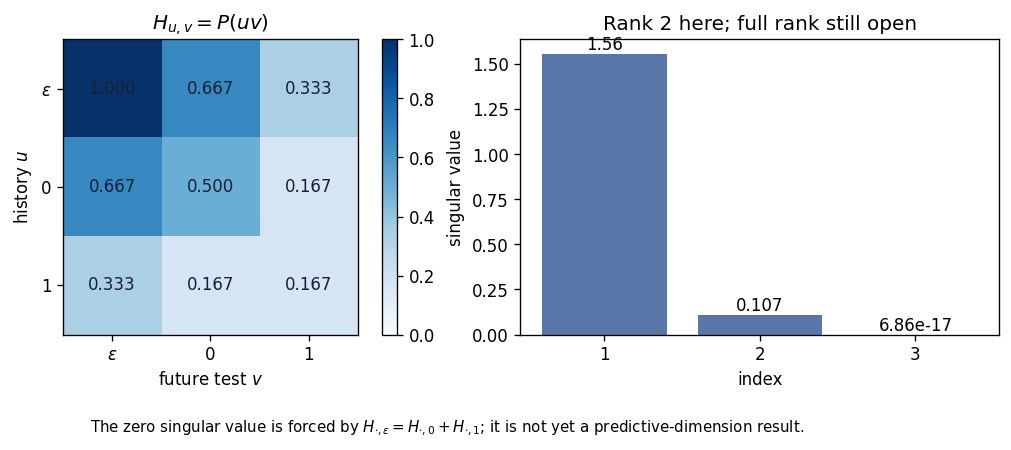

In [3]:
# VISUAL / CHECK — the joint Hankel block and its singular values.
labels = [r"$\epsilon$", "0", "1"]
H = np.array([
    [1,   2/3, 1/3],
    [2/3, 1/2, 1/6],
    [1/3, 1/6, 1/6],
], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.7))
image = axes[0].imshow(H, cmap="Blues", vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f"{H[i,j]:.3f}", ha="center",
                     va="center", color="#172033")
axes[0].set(xticks=range(3), xticklabels=labels,
            yticks=range(3), yticklabels=labels,
            xlabel="future test $v$", ylabel="history $u$",
            title=r"$H_{u,v}=P(uv)$")
fig.colorbar(image, ax=axes[0], fraction=.046)

singular_values = np.linalg.svd(H, compute_uv=False)
axes[1].bar(range(1, 4), singular_values, color="#5876a8")
axes[1].set(xticks=range(1, 4), xlabel="index",
            ylabel="singular value",
            title="Rank 2 here; full rank still open")
for i, value in enumerate(singular_values, start=1):
    axes[1].text(i, value, f"{value:.3g}", ha="center",
                 va="bottom")
fig.text(
    .5, .01,
    r"The zero singular value is forced by "
    r"$H_{\cdot,\epsilon}=H_{\cdot,0}+H_{\cdot,1}$; "
    "it is not yet a predictive-dimension result.",
    ha="center", fontsize=9,
)
plt.tight_layout(rect=(0, .07, 1, 1))
plt.show()


## CORE 3/5 — Normalize before comparing predictions (10 minutes)

A joint row is weighted by how likely its history was. A predictive
row instead contains conditional future probabilities:

$$
K_{u,v}=\Pr(v\mid u)=\frac{H_{u,v}}{\Pr(u)}
\quad\text{when }\Pr(u)>0.
$$

1. Normalize the rows for histories $\epsilon$, `0`, and `1`.
2. Form the additional joint row for history `10` and suffixes
   $\{\epsilon,0,1\}$ using the length-three table.
3. Show both

   $$
   H_{10,\cdot}=\frac14H_{0,\cdot}
   \quad\text{and}\quad
   K_{10,\cdot}=K_{0,\cdot}.
   $$

4. What is the difference between those two equalities?

<details><summary>Hint</summary>
$H_{10,\cdot}=(\Pr(10),\Pr(100),\Pr(101))$.
</details>


#### Worked solution

The three conditional rows are

$$
K_\epsilon=(1,2/3,1/3),\quad
K_0=(1,3/4,1/4),\quad
K_1=(1,1/2,1/2).
$$

For history `10`,

$$
H_{10,\cdot}=(1/6,1/8,1/24)
=\frac14(2/3,1/2,1/6)
=\frac14H_{0,\cdot}.
$$

Dividing by $\Pr(10)=1/6$ gives
$K_{10}=(1,3/4,1/4)=K_0$.

Proportional joint rows say that the two histories have the same
conditional predictions but occurred with different marginal
probabilities. Equal normalized rows directly compare predictions.


## CORE 4/5 — Predictive equivalence and its caveat (10 minutes)

Define two histories to be **predictively equivalent** when

$$
u\sim u'
\quad\Longleftrightarrow\quad
\Pr(v\mid u)=\Pr(v\mid u')
\ \text{for every finite future word }v.
$$

1. The finite table suggests that histories `0` and `10` are
   equivalent. Why does matching on the displayed suffixes alone
   not prove the definition?
2. Inspect the completed probabilities and hypothesize a simple rule
   for the process: what feature of the past appears to determine
   the distribution of the next symbol?
3. Under that hypothesis, identify the recurrent predictive states
   and label their symbol-conditioned transitions with probabilities.
   **STRETCH:** draw the graph before revealing the supplied version.
4. Is the empty history a third recurrent predictive state?

<details><summary>Hint</summary>
Compare histories ending in `0` with histories ending in `1`.
Observing the next symbol also tells you which class the new history
belongs to.
</details>


#### Worked solution

A finite block tests only finitely many futures. Two rows could agree
there and differ on a longer suffix, so full equivalence needs either
all future tests or additional structural knowledge.

The table is consistent with a first-order binary Markov source:

$$
\Pr(0\mid\text{last }0)=3/4,\qquad
\Pr(0\mid\text{last }1)=1/2.
$$

Thus histories ending in `0` form predictive state $C_0$ and those
ending in `1` form $C_1$:

$$
C_0\xrightarrow{0:3/4}C_0,\quad
C_0\xrightarrow{1:1/4}C_1,
$$

$$
C_1\xrightarrow{0:1/2}C_0,\quad
C_1\xrightarrow{1:1/2}C_1.
$$

The empty history carries the stationary mixture
$2/3\,C_0+1/3\,C_1$; it is an initial predictive mixture, not a third
recurrent class.


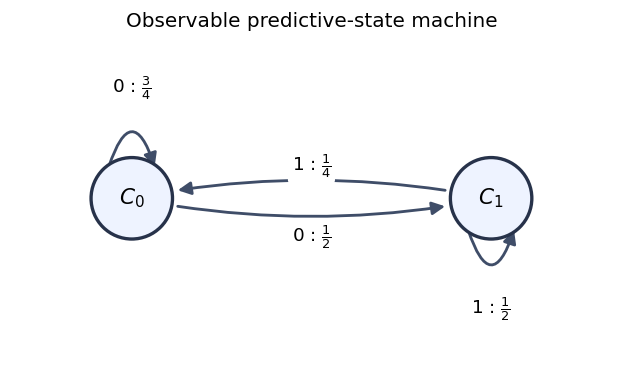

In [4]:
# VISUAL — the predictive machine inferred from observable rows.
from matplotlib.patches import Circle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(7.2, 3.5))
pos = {"C0": np.array([0.0, 0.0]), "C1": np.array([3.0, 0.0])}
for name, xy in pos.items():
    ax.add_patch(Circle(xy, .34, fc="#eef3ff", ec="#27324a",
                        lw=2, zorder=3))
    ax.text(*xy, rf"$C_{name[-1]}$", ha="center", va="center",
            fontsize=13, zorder=4)

def edge(a, b, label, rad, label_xy):
    ax.add_patch(FancyArrowPatch(
        pos[a], pos[b], arrowstyle="-|>", mutation_scale=16,
        shrinkA=28, shrinkB=28, lw=1.7, color="#3f4d68",
        connectionstyle=f"arc3,rad={rad}",
    ))
    ax.text(*label_xy, label, ha="center", va="center", fontsize=11,
            bbox=dict(boxstyle="round,pad=.2", fc="white", ec="none"))

edge("C0", "C1", r"1 : $\frac{1}{4}$", .10, (1.5, .27))
edge("C1", "C0", r"0 : $\frac{1}{2}$", .10, (1.5, -.32))

def loop(name, label, above=True):
    center = pos[name]
    y_offset = .24 if above else -.24
    start = center + np.array([-.20, y_offset])
    end = center + np.array([.20, y_offset])
    curvature = -1.55 if above else 1.55
    ax.add_patch(FancyArrowPatch(
        start, end, arrowstyle="-|>", mutation_scale=16,
        lw=1.7, color="#3f4d68",
        connectionstyle=f"arc3,rad={curvature}",
    ))
    label_y = .92 if above else -.92
    ax.text(center[0], label_y, label, ha="center", va="center",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=.2", fc="white", ec="none"))

loop("C0", r"0 : $\frac{3}{4}$", above=True)
loop("C1", r"1 : $\frac{1}{2}$", above=False)
ax.set(xlim=(-1, 4), ylim=(-1.35, 1.35), aspect="equal")
ax.axis("off")
ax.set_title("Observable predictive-state machine")
plt.show()


## CORE 5/5 — Choose predictions as coordinates (12 minutes)

A **predictive state representation** uses the probabilities of a
selected set of future experiments, or **core tests**, as state
coordinates.

Choose $\mathcal Q=\{\epsilon,0\}$ and define the normalized
predictive state

$$
q(u)=\big(\Pr(\epsilon\mid u),\Pr(0\mid u)\big)=(1,p).
$$

1. Give $p$ for $C_0$, $C_1$, and the empty history.
2. Express $\Pr(00\mid u)$ and $\Pr(10\mid u)$ in terms of $p$.
   **STRETCH:** derive the complementary `01` and `11` probabilities
   and verify that all four sum to one.
3. Derive the updated value $p'$ after observing `0`, and after
   observing `1`.
4. Why does the rank-two linear representation have only one free
   coordinate after normalization?

<details><summary>Hint 1</summary>
Condition on the first future symbol, then use the appropriate row
of the two-state predictive machine.
</details>

<details><summary>Hint 2</summary>
In general,
$\Pr(v\mid ux)=\Pr(xv\mid u)/\Pr(x\mid u)$.
</details>


#### Worked solution

The coordinate $p=\Pr(0\mid u)$ is $3/4$ in $C_0$, $1/2$ in $C_1$,
and $2/3$ initially. Conditioning on the first future symbol gives

$$
\Pr(00\mid u)=\frac34p,\qquad
\Pr(01\mid u)=\frac14p,
$$

$$
\Pr(10\mid u)=\frac12(1-p),\qquad
\Pr(11\mid u)=\frac12(1-p).
$$

After observing `0`, the new history ends in `0`, so $p'=3/4$.
After `1`, it ends in `1`, so $p'=1/2$. Equivalently these follow
by dividing the appropriate extended-test probabilities by
$\Pr(x\mid u)$.

The unnormalized linear state needs one coordinate for total mass
and one for predictive variation. Conditional states fix the mass
coordinate $\Pr(\epsilon\mid u)=1$, leaving a one-dimensional affine
set.


## CORE SYNTHESIS — Factorization, not ontology (8 minutes)

The finite table did not logically force a unique continuation to
all word lengths. From here, adopt the simplest first-order
continuation you reconstructed. It can be realized with two
edge-emitting matrices, using states $C_0,C_1$:

$$
T^{(0)}=
\begin{pmatrix}3/4&0\\1/2&0\end{pmatrix},
\qquad
T^{(1)}=
\begin{pmatrix}0&1/4\\0&1/2\end{pmatrix},
\qquad
\pi=(2/3,1/3).
$$

For any history $u$ and future test $v$, derive

$$
H_{u,v}
=\Pr(uv)
=\underbrace{\pi T^{(u)}}_{\text{history row}}
 \underbrace{T^{(v)}\mathbf 1}_{\text{future column}}.
$$

What rank bound follows for the **full infinite Hankel matrix**?
What additional statement would be unsafe to infer from finite rank
alone?


#### Worked solution

The word formula splits at the boundary between history and future:

$$
\Pr(uv)=\pi T^{(u)}T^{(v)}\mathbf1.
$$

Collecting $\pi T^{(u)}$ for all histories as rows and
$T^{(v)}\mathbf1$ for all tests as columns factors the **adopted
first-order process's full Hankel matrix** through a two-dimensional
space, so its full rank is at most two. Separately, the displayed
finite block is a submatrix with rank two, so the full rank is at
least two. These two logically distinct bounds establish that the
adopted continuation has full Hankel rank exactly two. The finite
table alone did not supply the upper bound.

More generally, finite Hankel rank guarantees a finite-dimensional
linear realization. It does not by itself guarantee that a
same-sized realization has nonnegative entries and stochastic HMM
semantics; nonnegative realization requires additional conditions.


## STRETCH — BELIEF ↔ PSR BRIDGE: longer tests recover Z1R belief (15–25 minutes)

Return to fair Z1R. Order the belief coordinates as
$(a,b,c)$ over $(S_0,S_1,S_R)$. Choose two observable tests:

$$
q_0=\Pr(0\mid h),\qquad q_{00}=\Pr(00\mid h).
$$

1. Derive $q_0$ and $q_{00}$ as functions of $(a,b,c)$.
2. Invert those equations to recover $(a,b,c)$ from
   $(q_0,q_{00})$.
3. Evaluate the coordinates after histories `01` and `10`. Which
   test separates the beliefs that one-step prediction merged?
4. Derive the coordinate update after observing `0`. Stretch:
   derive it after `1`.
5. Explain what this example does—and does not—show about the
   relationship between HMM beliefs and PSR coordinates.

<details><summary>Hint 1</summary>
From $S_0$, `0` is certain; from $S_1$, it is impossible; from
$S_R$, it has probability $1/2$. Two zeros in a row can begin only
from $S_R$.
</details>

<details><summary>Hint 2</summary>
Use $a+b+c=1$ after solving for $a$ and $c$.
</details>

**More open design route:** instead of the algebra above, modify
Z1R's random state or cyclic skeleton to create your own pair of
histories with equal next-token distributions and different longer
futures. Specify the smallest future-test set you found that
separates them.


#### Worked solution

From the three hidden phases,

$$
q_0=a+\frac12c,\qquad q_{00}=\frac12c.
$$

Therefore

$$
a=q_0-q_{00},\qquad
b=1-q_0-q_{00},\qquad
c=2q_{00}.
$$

After `01`, the belief is $(0,0,1)$, so
$(q_0,q_{00})=(1/2,1/2)$. After `10`, the belief is
$(1/2,1/2,0)$, so $(q_0,q_{00})=(1/2,0)$. The one-step test `0`
merges them; the longer test `00` separates them.

After observing `0`, Bayes' rule in predictive coordinates gives

$$
F_0(q_0,q_{00})
=\left(\frac{q_{00}}{q_0},0\right).
$$

The stretch update is

$$
F_1(q_0,q_{00})
=
\left(
\frac{1-q_0+q_{00}}{2(1-q_0)},
\frac{1-q_0-q_{00}}{2(1-q_0)}
\right),
$$

whenever the observed symbol has nonzero probability.

For this minimal Z1R realization, observable PSR coordinates and
HMM-belief coordinates are invertibly related. This does not make
arbitrary HMM beliefs canonical: a redundant realization can have
distinct hidden-state posteriors that induce the same distribution
over every observable future.


In [5]:
# CHECK — a small Z1R Hankel basis has rank 3.
# Prefix and suffix order: epsilon, 0, 00.
H_z1r = np.array([
    [1,   1/2, 1/6],
    [1/2, 1/6, 0],
    [1/6, 0,   0],
], dtype=float)
print(H_z1r)
print("rank:", np.linalg.matrix_rank(H_z1r))
print("determinant:", np.linalg.det(H_z1r))
print(
    "Interpretation: normalization plus two independent predictive "
    "coordinates, consistent with (q0, q00)."
)


[[1.     0.5    0.1667]
 [0.5    0.1667 0.    ]
 [0.1667 0.     0.    ]]
rank: 3
determinant: -0.0046296296296296285
Interpretation: normalization plus two independent predictive coordinates, consistent with (q0, q00).


---

# Optional WFA time-buffer branch

Stop here if the group needs consolidation time. The remaining
instructor demo shows how a finite Hankel basis yields linear
symbol-update operators. Students need only verify one word and
interpret the negative entry.


## INSTRUCTOR DEMO — Read observable symbol operators (8–10 minutes)

Use basis prefixes and suffixes
$\mathcal B=\{\epsilon,0\}$. Define

$$
B_{p,s}=\Pr(ps),\qquad
(B_x)_{p,s}=\Pr(pxs).
$$

Reading the supplied word table gives

$$
B=
\begin{pmatrix}1&2/3\\2/3&1/2\end{pmatrix},
\quad
B_0=
\begin{pmatrix}2/3&1/2\\1/2&3/8\end{pmatrix},
\quad
B_1=
\begin{pmatrix}1/3&1/6\\1/6&1/12\end{pmatrix}.
$$

The instructor now stacks the equations
$B_{p,\cdot}A_x=(B_x)_{p,\cdot}$ and solves $BA_x=B_x$, obtaining

$$
A_0=
\begin{pmatrix}0&0\\1&3/4\end{pmatrix},\qquad
A_1=
\begin{pmatrix}1&1/2\\-1&-1/2\end{pmatrix}.
$$

Let $\alpha=(1,2/3)$ be the empty-prefix row and let
$\omega=(1,0)^\top$ select the empty-suffix column.

1. Verify the single word

   $$
   \Pr(01)=\alpha A_0A_1\omega.
   $$

2. $A_1$ contains negative entries. Why are these not negative
   transition probabilities? What observable condition must the
   complete calculation still satisfy?

<details><summary>STRETCH — where did the operators come from?</summary>
Each row of $B$ represents a basis prefix. Appending $x$ should turn
it into the corresponding row of $B_x$, so stacking the row
equations gives $BA_x=B_x$ and $A_x=B^{-1}B_x$. The supplied check
cell performs this solve and tests several words.
</details>


#### Worked solution

Reading the entries from the word table gives

$$
B=
\begin{pmatrix}1&2/3\\2/3&1/2\end{pmatrix},
\qquad
B_0=
\begin{pmatrix}2/3&1/2\\1/2&3/8\end{pmatrix},
\qquad
B_1=
\begin{pmatrix}1/3&1/6\\1/6&1/12\end{pmatrix}.
$$

The row $B_{p,\cdot}$ is the observable coordinate row for prefix
$p$. After reading symbol $x$, it must become the row
$(B_x)_{p,\cdot}$ for prefix $px$. Requiring
$B_{p,\cdot}A_x=(B_x)_{p,\cdot}$ for both basis prefixes and stacking
the equations gives

$$
BA_x=B_x,\qquad A_x=B^{-1}B_x.
$$

Multiplying the blocks then gives

$$
A_0=B^{-1}B_0
=
\begin{pmatrix}
0&0\\
1&3/4
\end{pmatrix},
\qquad
A_1=B^{-1}B_1
=
\begin{pmatrix}
1&1/2\\
-1&-1/2
\end{pmatrix}.
$$

For example,

$$
\alpha A_0\omega=2/3=\Pr(0),
$$

and

$$
\alpha A_0A_1\omega=1/6=\Pr(01).
$$

Also
$\alpha A_1A_0A_1\omega=1/24=\Pr(101)$.

The entries of $A_x$ update an observable linear coordinate system;
they are not edge probabilities. Negative intermediate coordinates
are allowed as long as every complete word evaluation is a valid
nonnegative probability. This is a weighted finite automaton (or
observable operator realization), not automatically an HMM.


In [6]:
# CHECK — reconstructed WFA probabilities versus the source table.
B_basis = np.array([[1, 2/3], [2/3, 1/2]], dtype=float)
B0 = np.array([[2/3, 1/2], [1/2, 3/8]], dtype=float)
B1 = np.array([[1/3, 1/6], [1/6, 1/12]], dtype=float)
operators = [np.linalg.solve(B_basis, B0),
             np.linalg.solve(B_basis, B1)]
alpha = np.array([1.0, 2/3])
omega = np.array([1.0, 0.0])

def wfa_probability(word):
    state = alpha.copy()
    for symbol in word:
        state = state @ operators[int(symbol)]
    return float(state @ omega)

print("A0 =\n", operators[0])
print("A1 =\n", operators[1])
print()
for word in ["", "0", "1", "00", "01", "101", "111"]:
    expected = float(word_p[word])
    actual = wfa_probability(word)
    print(f"{word or 'epsilon':>7}: WFA={actual:.6f}, "
          f"table={expected:.6f}")


A0 =
 [[0.   0.  ]
 [1.   0.75]]
A1 =
 [[ 1.   0.5]
 [-1.  -0.5]]

epsilon: WFA=1.000000, table=1.000000
      0: WFA=0.666667, table=0.666667
      1: WFA=0.333333, table=0.333333
     00: WFA=0.500000, table=0.500000
     01: WFA=0.166667, table=0.166667
    101: WFA=0.041667, table=0.041667
    111: WFA=0.083333, table=0.083333


## Final synthesis

Complete this comparison:

| Object | Coordinates refer to | Update type | Canonical caveat |
|---|---|---|---|
| HMM belief | posterior over a chosen model's hidden states | normalized $\,\eta T^{(x)}\,$ | model-relative; may be redundant |
| Conditional Hankel row | probabilities of all future tests | conditioning by $\Pr(x\mid h)$ | infinite object |
| Finite PSR | probabilities of selected core tests | generally rational after normalization | tests must span the predictive space |
| WFA state | a finite linear coordinate basis | linear symbol operators | coordinates/operators need not be nonnegative |

In one sentence, state what remains invariant when we change among
valid coordinate systems.


#### Worked solution

What remains invariant is the observable stochastic process: every
valid realization must assign the same probability to every finite
word, even though its state coordinates, geometry under arbitrary
metrics, and update matrices may look different.
